# Datasets Combination

Merge all cleaned datasets into one

## A. List of datasets

### A.1. CrisisLexT6

### A.2. CrisisLexT26

### A.3. CrisisMMD

### A.4. CrisisNLP_R1

## B. Merge

### B.1. Columns

### B.1. Columns

In [2]:
from pathlib import Path
# import os
import pandas as pd

import configuration
from src import dataset_settings

# from dotenv import load_dotenv
# load_dotenv()

all_files = sorted(Path('datasets').rglob('*.csv'))
print(f"Found {len(all_files)} CSV files in the datasets directory.")
for f in all_files:
    print(f" - {f}")

df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)

# df = pd.read_csv(all_files[1])

Found 5 CSV files in the datasets directory.
 - datasets/ACL_ICWSM_2018.csv
 - datasets/CrisisLexT26.csv
 - datasets/CrisisLexT6.csv
 - datasets/CrisisMMD_v2.csv
 - datasets/CrisisNLP.csv


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135884 entries, 0 to 135883
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   tweet_id        135884 non-null  int64 
 1   tweet_text      135884 non-null  object
 2   relevant        135884 non-null  bool  
 3   event_type      135884 non-null  object
 4   event_name      135884 non-null  object
 5   dataset         135884 non-null  object
 6   original_label  135884 non-null  object
 7   country         135884 non-null  object
 8   year            135884 non-null  int64 
 9   meta            135884 non-null  object
dtypes: bool(1), int64(2), object(7)
memory usage: 9.5+ MB


In [4]:
df.describe()

,tweet_id,year
count,1.358840e+05,135884.000000
mean,4.969573e+17,1959.056357
std,2.124786e+17,328.389211
min,2.034409e+17,-1.000000
25%,2.973236e+17,2013.000000
50%,5.013115e+17,2014.000000
75%,5.926249e+17,2015.000000
max,9.320276e+17,2017.000000


In [5]:
df.head()

,tweet_id,tweet_text,relevant,event_type,event_name,dataset,original_label,country,year,meta
0,591902739002560512,RT @AnupKaphle: #Nepal's prime minister addres...,True,earthquake,2015 Nepal Earthquake,ACL_ICWSM_2018,relevant,Nepal,2015,"{""file_name"": ""nepal/2015_Nepal_Earthquake_tra..."
1,592939706788216832,@jonsnowC4 So have we; read our friends blog f...,True,earthquake,2015 Nepal Earthquake,ACL_ICWSM_2018,relevant,Nepal,2015,"{""file_name"": ""nepal/2015_Nepal_Earthquake_tra..."
2,592591542168252416,Lend a helping hand if you can #Nepal https://...,True,earthquake,2015 Nepal Earthquake,ACL_ICWSM_2018,relevant,Nepal,2015,"{""file_name"": ""nepal/2015_Nepal_Earthquake_tra..."
3,591903009279385600,@shilpaanand they've managed to reach Kathmand...,True,earthquake,2015 Nepal Earthquake,ACL_ICWSM_2018,relevant,Nepal,2015,"{""file_name"": ""nepal/2015_Nepal_Earthquake_tra..."
4,592099765271199744,Israel Sending Aid Teams to Nepal After Quake:...,True,earthquake,2015 Nepal Earthquake,ACL_ICWSM_2018,relevant,Nepal,2015,"{""file_name"": ""nepal/2015_Nepal_Earthquake_tra..."


Datasets List

In [6]:
df[df['dataset']=='Related and informative']

,tweet_id,tweet_text,relevant,event_type,event_name,dataset,original_label,country,year,meta


<Axes: xlabel='dataset'>

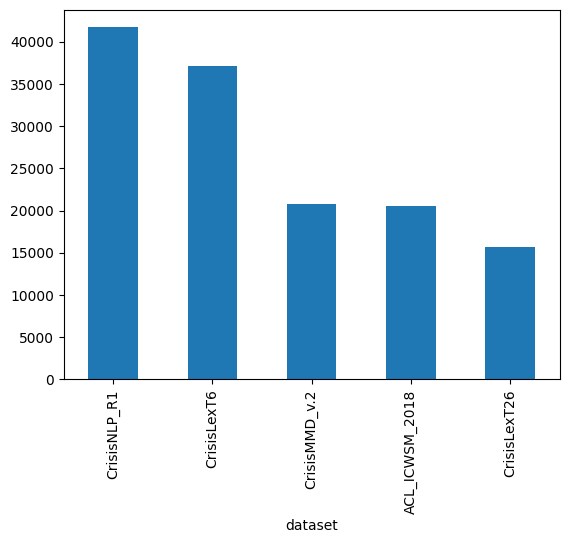

In [7]:
df['dataset'].value_counts().plot(kind='bar')

<Axes: xlabel='event_type'>

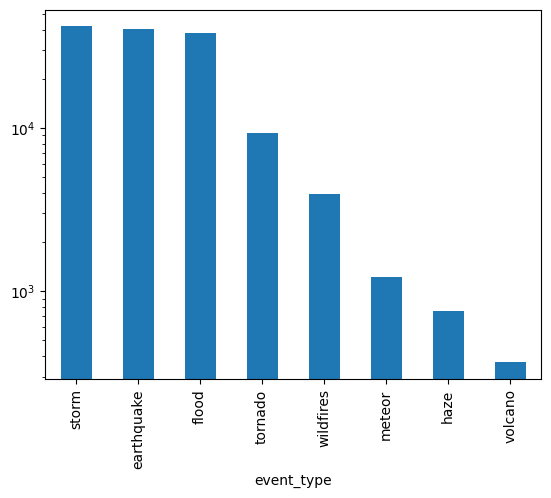

In [8]:
df['event_type'].value_counts().plot(kind='bar', logy=True)

Text(0.5, 1.0, 'Number of event_name entries for each event_type')

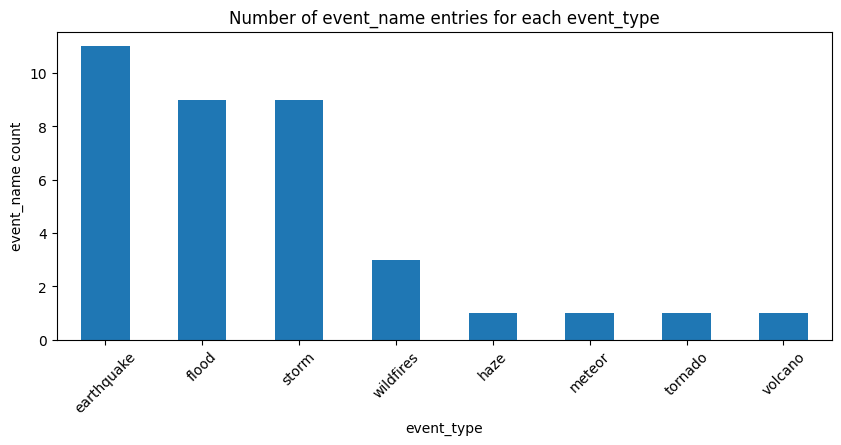

In [9]:
event_name_count_by_type = (
    df.groupby('event_type')['event_name']
      .nunique()
      .sort_values(ascending=False)
)

ax = event_name_count_by_type.plot(kind='bar', figsize=(10, 4), rot=45)
ax.set_xlabel('event_type')
ax.set_ylabel('event_name count')
ax.set_title('Number of event_name entries for each event_type')

In [10]:
event_name_count_by_type.head()

event_type
earthquake    11
flood          9
storm          9
wildfires      3
haze           1
Name: event_name, dtype: int64

<Axes: xlabel='relevant'>

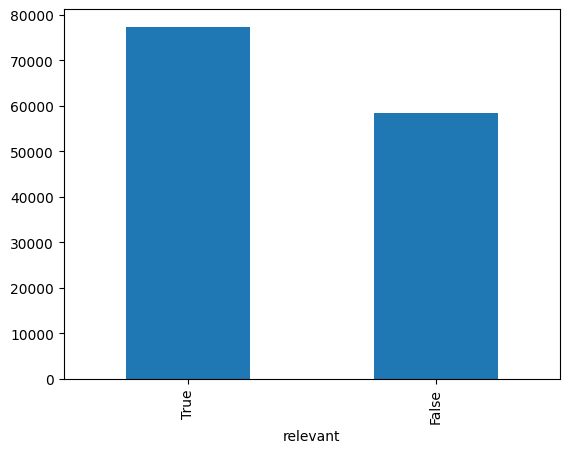

In [11]:
df['relevant'].value_counts().plot(kind='bar')

In [ ]:
import csv

df.to_csv('datasets/unified_dataset.csv', index=False, quoting=csv.QUOTE_ALL)

In [13]:
df.head()

,tweet_id,tweet_text,relevant,event_type,event_name,dataset,original_label,country,year,meta
0,591902739002560512,RT @AnupKaphle: #Nepal's prime minister addres...,True,earthquake,2015 Nepal Earthquake,ACL_ICWSM_2018,relevant,Nepal,2015,"{""file_name"": ""nepal/2015_Nepal_Earthquake_tra..."
1,592939706788216832,@jonsnowC4 So have we; read our friends blog f...,True,earthquake,2015 Nepal Earthquake,ACL_ICWSM_2018,relevant,Nepal,2015,"{""file_name"": ""nepal/2015_Nepal_Earthquake_tra..."
2,592591542168252416,Lend a helping hand if you can #Nepal https://...,True,earthquake,2015 Nepal Earthquake,ACL_ICWSM_2018,relevant,Nepal,2015,"{""file_name"": ""nepal/2015_Nepal_Earthquake_tra..."
3,591903009279385600,@shilpaanand they've managed to reach Kathmand...,True,earthquake,2015 Nepal Earthquake,ACL_ICWSM_2018,relevant,Nepal,2015,"{""file_name"": ""nepal/2015_Nepal_Earthquake_tra..."
4,592099765271199744,Israel Sending Aid Teams to Nepal After Quake:...,True,earthquake,2015 Nepal Earthquake,ACL_ICWSM_2018,relevant,Nepal,2015,"{""file_name"": ""nepal/2015_Nepal_Earthquake_tra..."


In [ ]:
import numpy as np
import pandas as pd

def stratified_dev_subset(df, frac=0.10, strat_cols=None, random_state=42):
    if strat_cols is None:
        raise ValueError("strat_cols must be provided for stratified sampling.")

    n_total = len(df)
    n_target = int(round(n_total * frac))

    # Size of each joint stratum
    stratum_sizes = df.groupby(strat_cols, dropna=False).size()

    # Proportional allocation (largest remainder method)
    ideal = stratum_sizes / n_total * n_target
    alloc = np.floor(ideal).astype(int)
    remainder = ideal - alloc

    diff = n_target - int(alloc.sum())
    if diff > 0:
        # Add 1 to strata with largest fractional remainder
        alloc.loc[remainder.sort_values(ascending=False).index[:diff]] += 1
    elif diff < 0:
        # Remove 1 from strata with smallest remainder (only where alloc > 0)
        removable = alloc[alloc > 0].index
        drop_idx = remainder.loc[removable].sort_values(ascending=True).index[:(-diff)]
        alloc.loc[drop_idx] -= 1

    # Sample from each stratum
    grouped = df.groupby(strat_cols, dropna=False, sort=False)
    parts = []
    for key, n in alloc.items():
        if n <= 0:
            continue
        g = grouped.get_group(key)
        n = min(n, len(g))  # safety
        parts.append(g.sample(n=n, random_state=random_state))

    dev_df = pd.concat(parts).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return dev_df

# ---- use it ----
strat_cols = ["relevant", "event_type", "event_name", "dataset", "original_label", "country", "year"]
dev_df = stratified_dev_subset(df, frac=0.10, strat_cols=strat_cols, random_state=42)

print(f"Original size: {len(df)}")
print(f"Dev size:      {len(dev_df)}")

Original size: 135884
Dev size:      13588


In [15]:
for c in strat_cols:
    comp = pd.concat(
        [df[c].value_counts(normalize=True).rename("full"),
         dev_df[c].value_counts(normalize=True).rename("dev")],
        axis=1
    ).fillna(0)
    print(f"\n=== {c} ===")
    print((comp * 100).round(2))


=== relevant ===
           full    dev
relevant              
True      56.94  56.95
False     43.06  43.05

=== event_type ===
             full    dev
event_type              
storm       30.79  30.77
earthquake  29.51  29.51
flood       28.22  28.25
tornado      6.85   6.85
wildfires    2.90   2.88
meteor       0.90   0.91
haze         0.56   0.56
volcano      0.27   0.27

=== event_name ===
                                   full    dev
event_name                                    
2015 Nepal Earthquake             17.61  17.63
2013 Queensland Floods            14.13  14.13
2014 Philippines Typhoon Hagupit   8.44   8.43
2013 Alberta Floods                7.63   7.62
2012 Sandy Hurricane               6.94   6.94
2013 Oklahoma Tornado              6.85   6.85
hurricane_maria                    3.92   3.92
hurricane_harvey                   3.76   3.76
hurricane_irma                     3.41   3.41
Landslides Worldwide               2.73   2.73
2015 Cyclone Pam                   1